# Time to do some analysis based on the forest's predictions...
# This part might need a vhmem node from Sulis

In [1]:
import os
import pickle

import pandas as pd
import numpy as np

from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import matthews_corrcoef, roc_auc_score, r2_score, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

import seaborn as sns

import plotly.express as px
from plotly import graph_objects as go

import dask
import dask.dataframe as dd
from dask.distributed import Client, LocalCluster

In [2]:
# Note, we could read from the simplified csv, but reading the full thing with dask is actually faster
cluster = LocalCluster(threads_per_worker=1, n_workers=32, memory_limit='64GB')
client = Client(cluster)

pred_df = dd.read_parquet('pred_pubchem.parquet')
print(pred_df.columns)
print(len(pred_df))

simplified_df = pred_df[['idx', 'InChIID', 'InChIKey', 'SMILES', 'MolWt', 'LogP', 'BBB+', 'logBB']]
simplified_df = simplified_df.compute()
print(simplified_df.head())

#if not os.path.exists('pred_pubchem_simplified.csv'):
#    print('Not detecting existing CSV, writing a simplified one to file, this may take a while')
#    simplified_df.to_csv('pred_pubchem_simplified.csv')

Index(['idx', 'InChIID', 'InChIKey', 'MolWt', 'LogP', 'SMILES', 'C1CCSNC1',
       'C1CNOC1', 'BC', 'C1=CCCN2CCCC(CC1)C2',
       ...
       'C1=COCNC1', 'C1CCNCCCCNCCNCCNCCNCCNCC1', 'BO', 'C1=COCCO1',
       'C1=NCCCC1', 'C1=CCCC=CC=CCC2CCC(CCC=C1)OC2', 'C1COCN1', 'C1CCOC1',
       'BBB+', 'logBB'],
      dtype='object', length=401)
112194965
   idx                                            InChIID  \
0    1  InChI=1S/C9H17NO4/c1-7(11)14-8(5-9(12)13)6-10(...   
1    2  InChI=1S/C9H17NO4/c1-7(11)14-8(5-9(12)13)6-10(...   
2    3  InChI=1S/C7H8O4/c8-5-3-1-2-4(6(5)9)7(10)11/h1-...   
3    4         InChI=1S/C3H9NO/c1-3(5)2-4/h3,5H,2,4H2,1H3   
4    5  InChI=1S/C3H8NO5P/c4-1-3(5)2-9-10(6,7)8/h1-2,4...   

                      InChIKey                            SMILES       MolWt  \
0  RDHQFKQIGNGIED-UHFFFAOYSA-N  CC(=O)OC(CC(=O)[O-])C[N+](C)(C)C  203.238007   
1  RDHQFKQIGNGIED-UHFFFAOYSA-O     CC(=O)OC(CC(=O)O)C[N+](C)(C)C  204.246002   
2  INCSWYKICIYAHB-UHFFFAOYSA-N              O=C

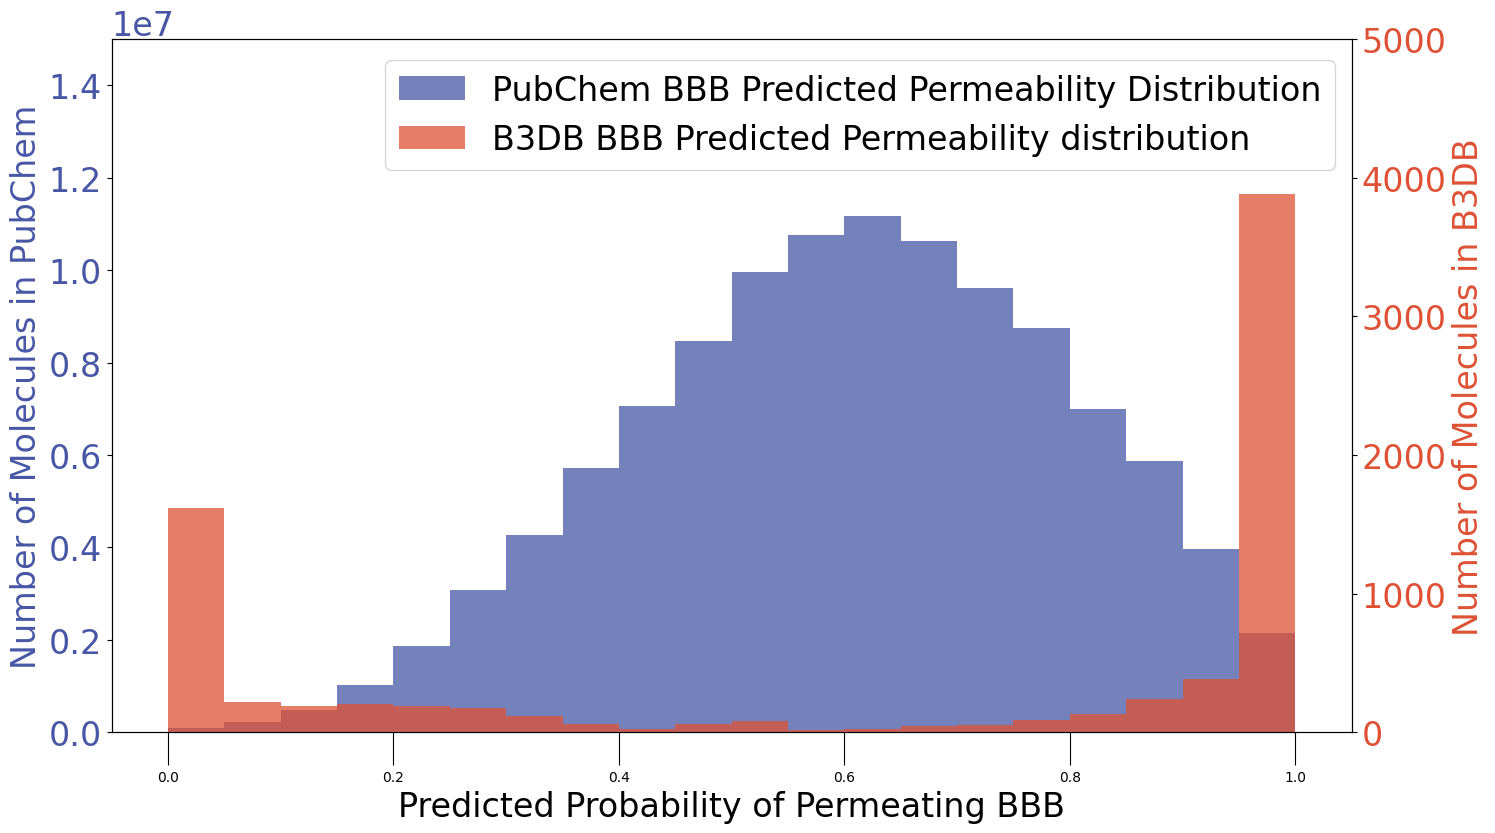

In [3]:
clf = pickle.load(open('forest_clf.pickle', 'rb'))
#rgr = pickle.load(open('forest_rgr.pickle', 'rb'))

vocab_data = dd.read_parquet('./B3DB/B3DB_classification_clean.parquet').compute()
with open('./B3DB/B3DB_classification_clean.parquet.vocab', 'rb') as f:
    vocab, mol_dict = pickle.load(f)

X = vocab_data[vocab]
y = (vocab_data['BBB+/BBB-'] == 'BBB+')
X_logbb = vocab_data.dropna(subset=['logBB'])[vocab]
y_logbb = vocab_data.dropna(subset=['logBB'])['logBB']

p_b3db = clf.predict_proba(X)[:, 1]

fig, ax1 = plt.subplots(figsize=(16, 9))

colour_pubchem = '#4757a5'
ax1.set_xlabel('Predicted Probability of Permeating BBB', fontsize=24)
ax1.set_ylabel('Number of Molecules in PubChem', color=colour_pubchem, fontsize=24)
ax1.tick_params(axis='y', labelcolor=colour_pubchem, labelsize=24)
ax1.tick_params(axis='x', size=24)
ax1.yaxis.get_offset_text().set_size(24)

h1 = ax1.hist(simplified_df['BBB+'], bins=20, alpha=0.75, color=colour_pubchem, label='PubChem BBB Predicted Permeability Distribution')
np.savetxt("hist_pubchem.csv", h1[0])
np.savetxt("histbins_pubchem.csv", h1[1])

colour_b3db = '#de5134'
ax2 = ax1.twinx()
ax2.set_ylabel('Number of Molecules in B3DB', color=colour_b3db, fontsize=24)
ax2.tick_params(axis='y', labelcolor=colour_b3db, labelsize=24)

h2 = ax2.hist(p_b3db, bins=20, alpha=0.75, color=colour_b3db, label='B3DB BBB Predicted Permeability distribution')
np.savetxt("hist_b3db.csv", h2[0])
np.savetxt("histbins_b3db.csv", h2[1])

ax1.set_ylim(0, 1.5e7)
ax2.set_ylim(0, 5000)
fig.legend(fontsize=24, loc='upper right', bbox_to_anchor=(0.9, 0.875))
fig.savefig('histogram_bbbp.png')

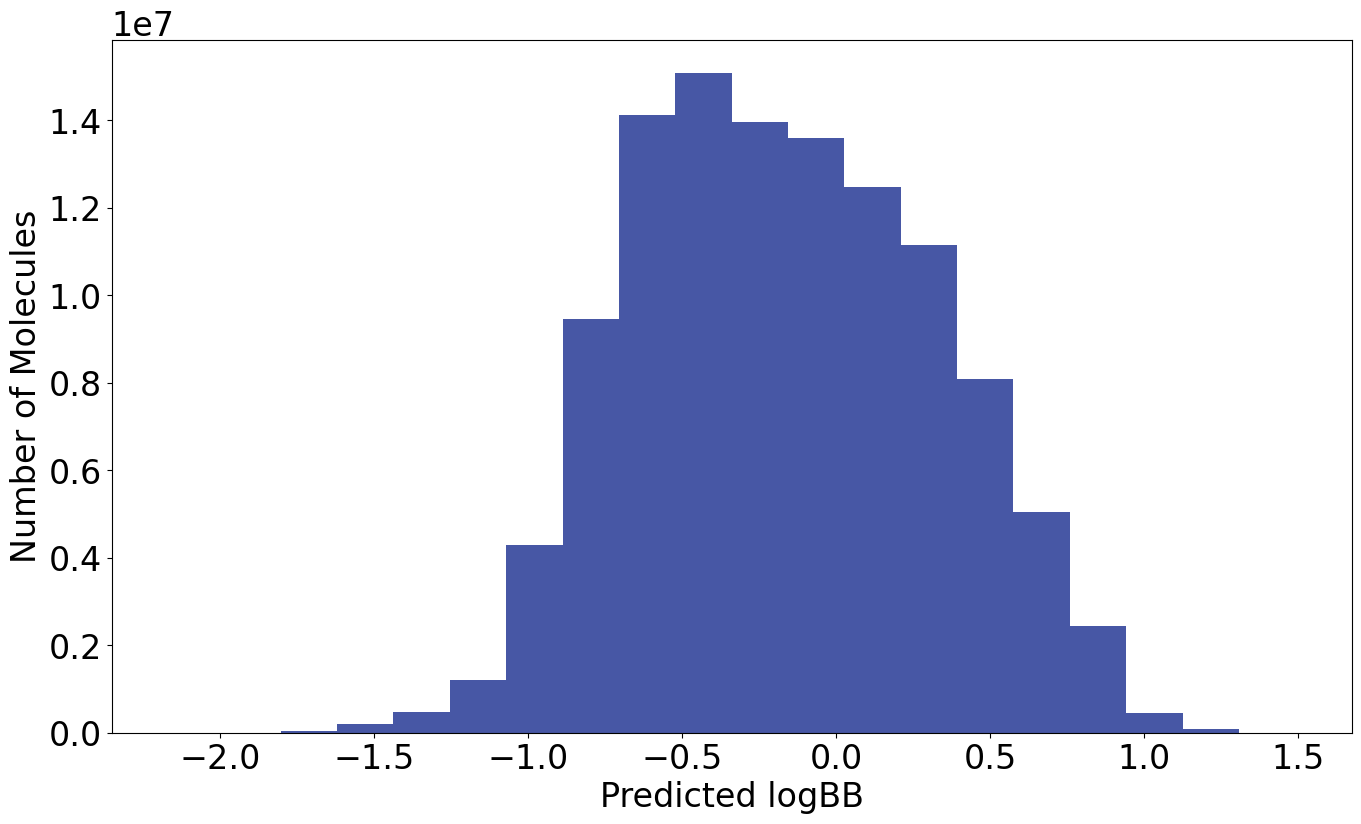

In [4]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['logBB'], bins=20, color=colour_pubchem)
plt.xlabel('Predicted logBB', fontsize=24)
plt.ylabel('Number of Molecules', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)
plt.savefig('histogram logbb.png')

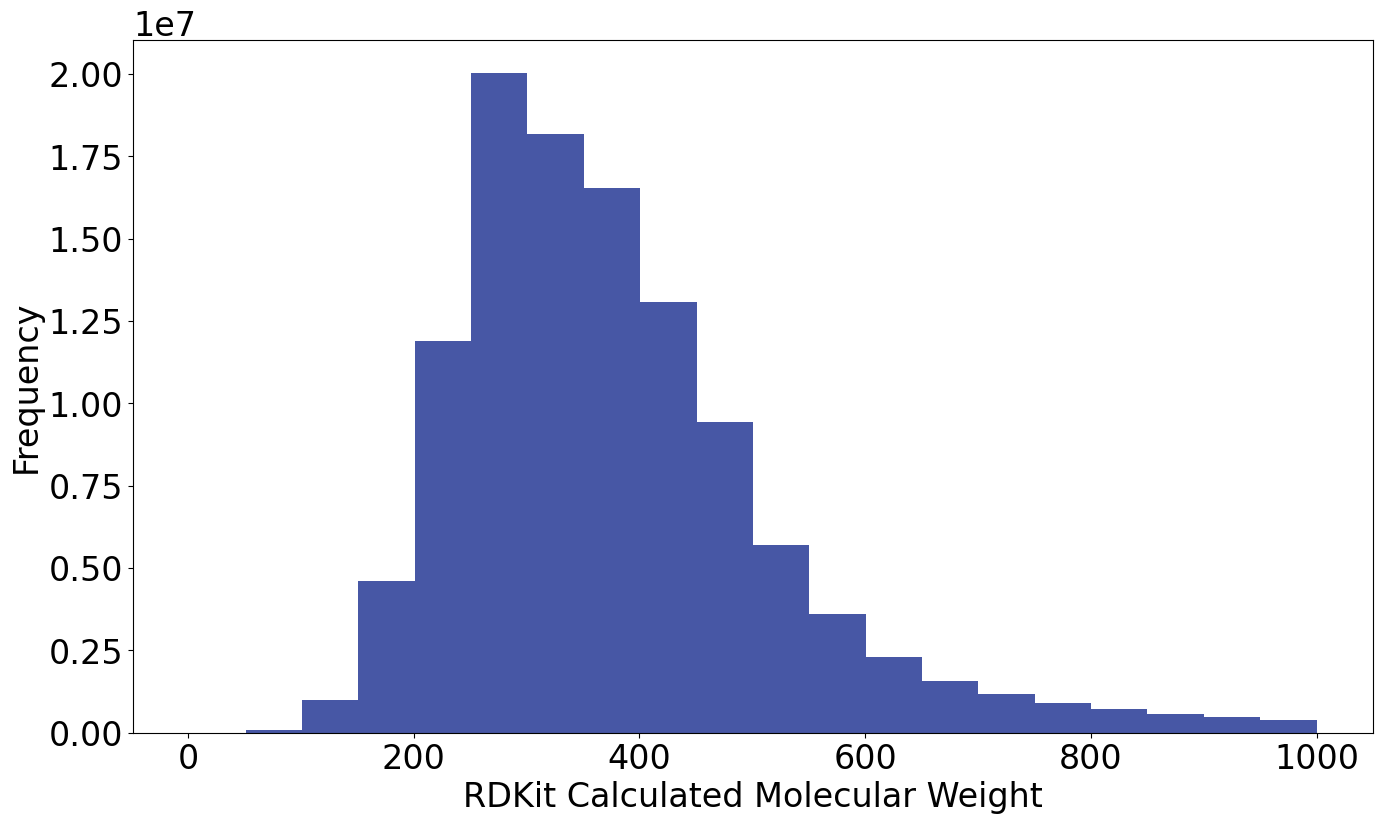

In [5]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['MolWt'], bins=20, color=colour_pubchem)
plt.xlabel('RDKit Calculated Molecular Weight', fontsize=24)
plt.ylabel('Frequency', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)

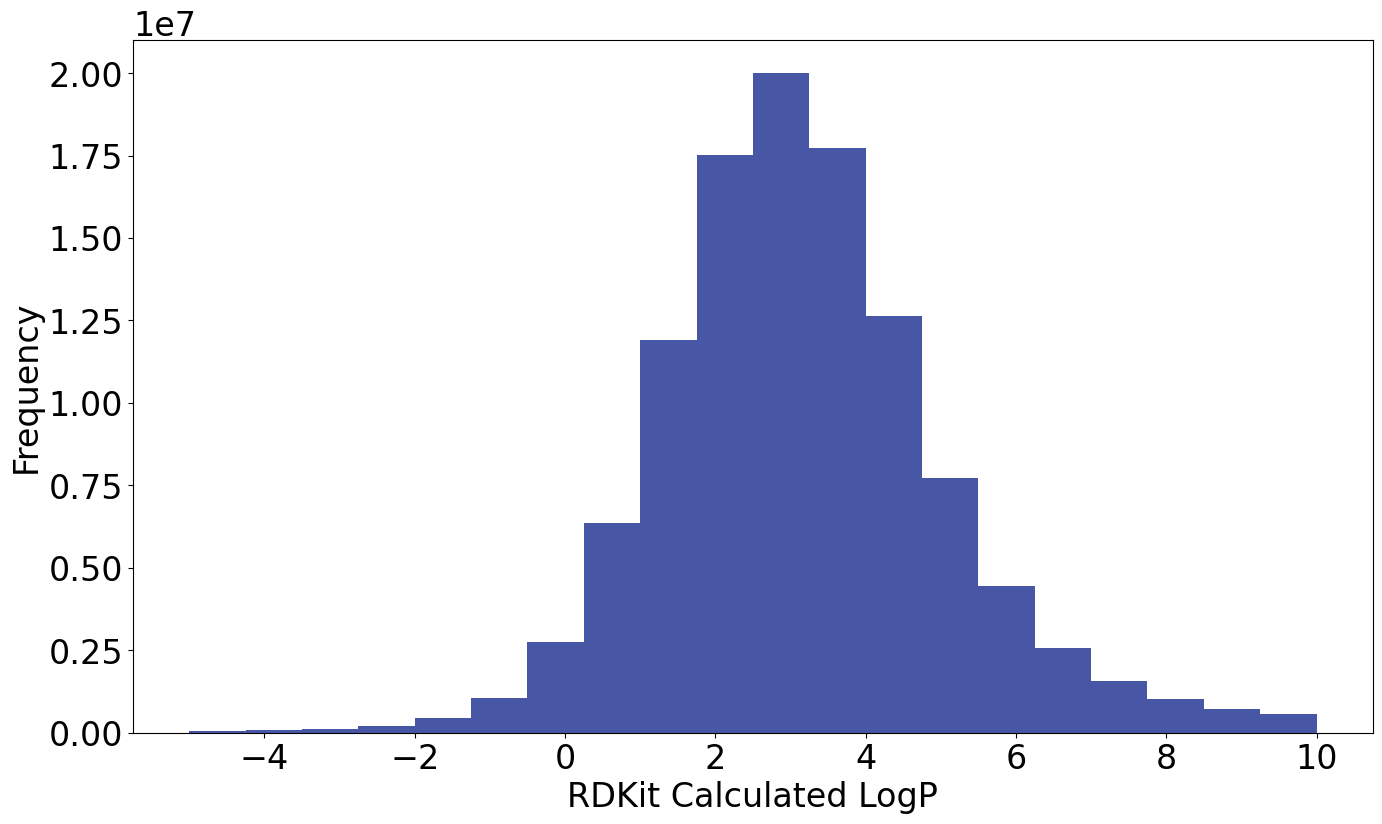

In [6]:
plt.figure(figsize=(16, 9))
plt.hist(simplified_df['LogP'], bins=20, range=(-5,10), color=colour_pubchem)
plt.xlabel('RDKit Calculated LogP', fontsize=24)
plt.ylabel('Frequency', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.gca().yaxis.get_offset_text().set_size(24)

# So, reviewers have asked us for a few things
## The first of these is to look at the actual similarity between PubChem, B3DB and our candidates
## We could do this with MCES like this paper https://www.biorxiv.org/content/10.1101/2023.03.27.534311v1
## But, that's slow and complicated. Let's go with Morgan Fingerprints with Tanimoto/Jaccard distance

In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys
from rdkit import DataStructs
import umap

def compute_morgan(inchi):
    morgan_vector = np.zeros((2048,), dtype=np.int8)
    try:
        mol = Chem.MolFromInchi(inchi)
        morgan_fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=3, nBits=2048)

        DataStructs.ConvertToNumpyArray(morgan_fp, morgan_vector)
    except:
        pass

    return morgan_vector

def compute_maccs(inchi):
    maccs_vector = np.zeros((167,), dtype=np.int8)

    try:
        mol = Chem.MolFromInchi(inchi)
        maccs_fp = MACCSkeys.GenMACCSKeys(mol)

        DataStructs.ConvertToNumpyArray(maccs_fp, maccs_vector)
    except:
        pass

    return maccs_vector

In [8]:
vocab_data['Morgan'] = vocab_data['Inchi'].map(compute_morgan)
vocab_data['MACCS'] = vocab_data['Inchi'].map(compute_maccs)

RDKit WARNING: [03:38:26] WARNING: not removing hydrogen atom without neighbors
[03:38:26] WARNING: not removing hydrogen atom without neighbors
RDKit ERROR: [03:38:29] Explicit valence for atom # 10 N, 4, is greater than permitted
[03:38:29] Explicit valence for atom # 10 N, 4, is greater than permitted
RDKit WARNING: [03:38:26] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)
[03:38:26] WARNING:  Problems/mismatches: Mobile-H( Mobile-H groups: Attachment points, Number)
[03:38:32] WARNING: not removing hydrogen atom without neighbors
RDKit WARNING: [03:38:32] WARNING: not removing hydrogen atom without neighbors
RDKit ERROR: [03:38:29] ERROR: Explicit valence for atom # 10 N, 4, is greater than permitted
[03:38:29] ERROR: Explicit valence for atom # 10 N, 4, is greater than permitted
[03:38:41] Explicit valence for atom # 10 N, 4, is greater than permitted
RDKit ERROR: [03:38:41] Explicit valence for atom # 10 N, 4, is greater than permitted


In [9]:
pos_cand = pd.read_csv('../common/candidates/bbbp_positive_pubchem.csv', comment=';')
neg_cand = pd.read_csv('../common/candidates/bbbp_negative_pubchem.csv', comment=';')

pos_cand['Morgan'] = pos_cand['InChIID'].map(compute_morgan)
pos_cand['MACCS'] = pos_cand['InChIID'].map(compute_maccs)
neg_cand['Morgan'] = neg_cand['InChIID'].map(compute_morgan)
neg_cand['MACCS'] = neg_cand['InChIID'].map(compute_maccs)

In [10]:
# Take a 100k subset from our full PubChem dataset
# pred_df = pred_df.set_index('idx')
# idx = np.random.choice(pred_df.index.compute(), size=100000, replace=False)
# pubchem_umap = np.stack(pred_df['InChIID'][idx].map(compute_morgan, meta=pd.Series(dtype=np.uint8, name='Morgan')).compute(), axis=0)

# b3db_umap = np.stack(vocab_data['Morgan'], axis=0)
# pos_umap = np.stack(pos_cand['Morgan'], axis=0)
# neg_umap = np.stack(neg_cand['Morgan'], axis=0)


# reducer = umap.UMAP(metric='jaccard', n_neighbors=100, min_dist=0.1, n_components=2, random_state=1209)

# pubchem_umap = reducer.fit_transform(pubchem_umap)

# b3db_umap = reducer.transform(b3db_umap)
# pos_umap = reducer.transform(pos_umap)
# neg_umap = reducer.transform(neg_umap)

# np.save('pubchem_morgan_umap.npy', pubchem_umap)
# np.save('b3db_morgan_umap.npy', b3db_umap)
# np.save('pos_morgan_umap.npy', pos_umap)
# np.save('neg_morgan_umap.npy', neg_umap)

pubchem_umap = np.load('pubchem_morgan_umap.npy')
b3db_umap = np.load('b3db_morgan_umap.npy')
pos_umap = np.load('pos_morgan_umap.npy')
neg_umap = np.load('neg_morgan_umap.npy')

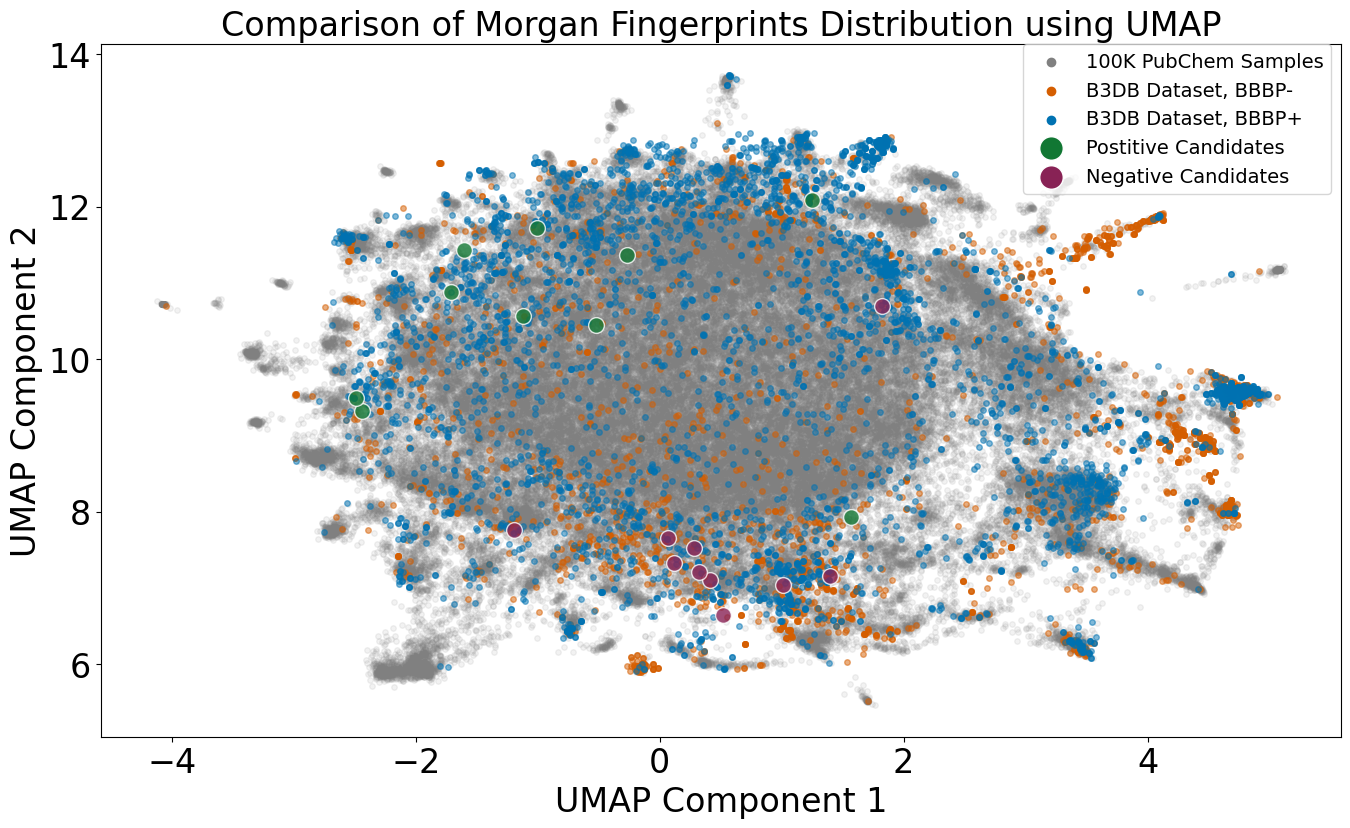

In [11]:
fig, ax = plt.subplots(figsize=(16, 9))

ax.scatter(
    pubchem_umap[:, 0], pubchem_umap[:, 1],
    s=16, color='gray', label='100K PubChem Samples', alpha=0.1, zorder=1)

ax.scatter(
    b3db_umap[vocab_data['BBB+/BBB-']=='BBB-', 0,], b3db_umap[vocab_data['BBB+/BBB-']=='BBB-', 1],
    s=16, color='#D55E00', label='B3DB Dataset, BBBP-', alpha=0.5, zorder=2)
ax.scatter(
    b3db_umap[vocab_data['BBB+/BBB-']=='BBB+', 0,], b3db_umap[vocab_data['BBB+/BBB-']=='BBB+', 1],
    s=16, color='#0072B2', label='B3DB Dataset, BBBP+', alpha=0.5, zorder=2)

ax.scatter(
    pos_umap[:, 0], pos_umap[:, 1],
    s=128, color='#117733', edgecolors='white', alpha=0.8, zorder=3, label='Postitive Candidates')
ax.scatter(
    neg_umap[:, 0], neg_umap[:, 1],
    s=128, color='#882255', edgecolors='white', alpha=0.8, zorder=3, label='Negative Candidates')

ax.set_title('Comparison of Morgan Fingerprints Distribution using UMAP', fontsize=24)
ax.set_xlabel('UMAP Component 1', fontsize=24)
ax.set_ylabel('UMAP Component 2', fontsize=24)
ax.tick_params(axis='y', labelsize=24)
ax.tick_params(axis='x', labelsize=24)

leg = fig.legend(fontsize=14, markerscale=1.5, loc='upper right', bbox_to_anchor=(0.9, 0.89))

# 2. Force the alpha of all icons in the legend to 1.0
for lh in leg.legend_handles:
    lh.set_alpha(1.0)

fig.savefig('umap_morgan.png', dpi=300, bbox_inches='tight')

In [12]:
# Take a 100k subset from our full PubChem dataset
# pred_df = pred_df.set_index('idx')
# idx = np.random.choice(pred_df.index.compute(), size=100000, replace=False)
# pubchem_umap = np.stack(pred_df['InChIID'][idx].map(compute_maccs, meta=pd.Series(dtype=np.uint8, name='MACCS')).compute(), axis=0)

# b3db_umap = np.stack(vocab_data['MACCS'], axis=0)
# pos_umap = np.stack(pos_cand['MACCS'], axis=0)
# neg_umap = np.stack(neg_cand['MACCS'], axis=0)

# reducer = umap.UMAP(metric='jaccard', n_neighbors=100, min_dist=0.1, n_components=2, random_state=1209)

# pubchem_umap = reducer.fit_transform(pubchem_umap)

# b3db_umap = reducer.transform(b3db_umap)
# pos_umap = reducer.transform(pos_umap)
# neg_umap = reducer.transform(neg_umap)

# np.save('pubchem_maccs_umap.npy', pubchem_umap)
# np.save('b3db_maccs_umap.npy', b3db_umap)
# np.save('pos_maccs_umap.npy', pos_umap)
# np.save('neg_maccs_umap.npy', neg_umap)

pubchem_umap = np.load('pubchem_maccs_umap.npy')
b3db_umap = np.load('b3db_maccs_umap.npy')
pos_umap = np.load('pos_maccs_umap.npy')
neg_umap = np.load('neg_maccs_umap.npy')

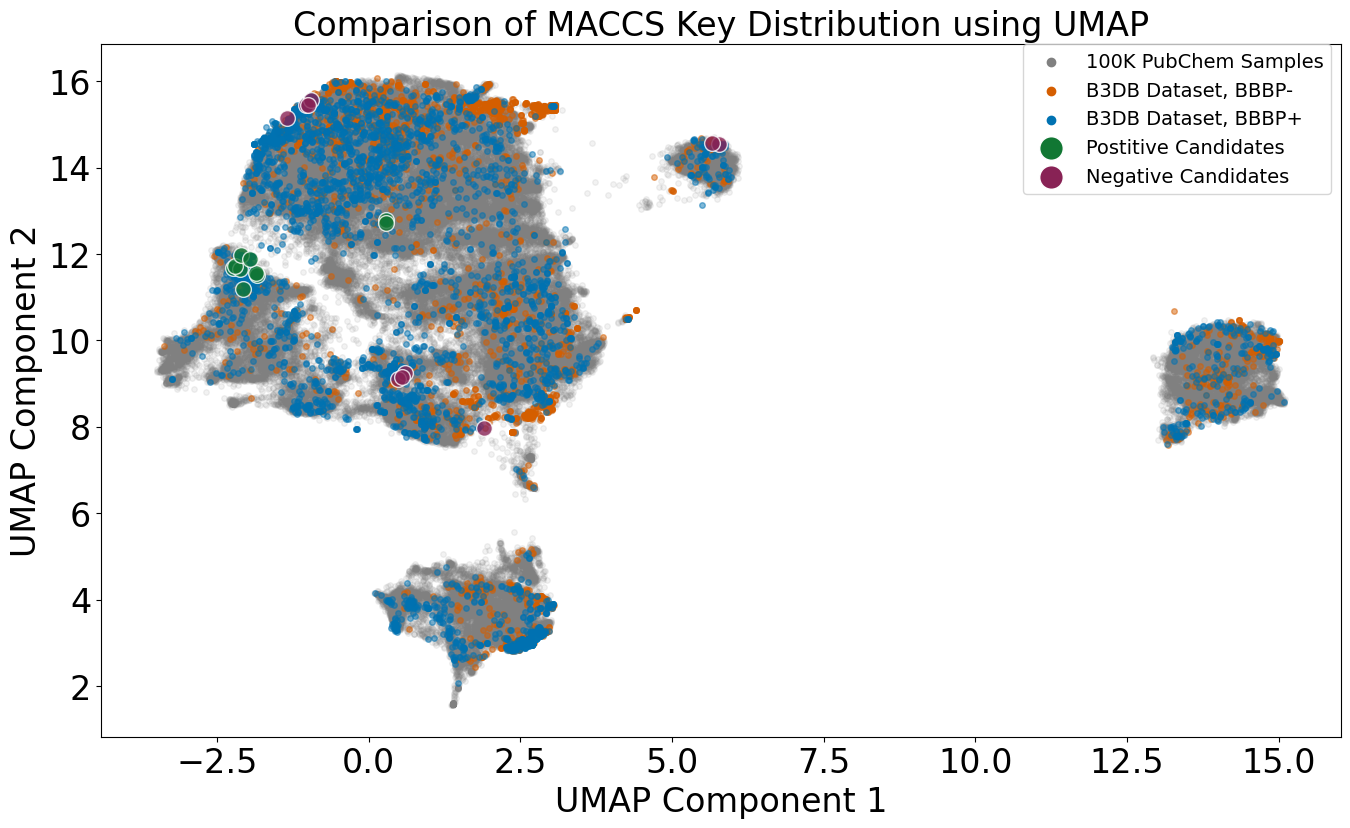

In [13]:
fig, ax = plt.subplots(figsize=(16, 9))

ax.scatter(
    pubchem_umap[:, 0], pubchem_umap[:, 1],
    s=16, color='gray', label='100K PubChem Samples', alpha=0.1, zorder=1)

ax.scatter(
    b3db_umap[vocab_data['BBB+/BBB-']=='BBB-', 0,], b3db_umap[vocab_data['BBB+/BBB-']=='BBB-', 1],
    s=16, color='#D55E00', label='B3DB Dataset, BBBP-', alpha=0.5, zorder=2)
ax.scatter(
    b3db_umap[vocab_data['BBB+/BBB-']=='BBB+', 0,], b3db_umap[vocab_data['BBB+/BBB-']=='BBB+', 1],
    s=16, color='#0072B2', label='B3DB Dataset, BBBP+', alpha=0.5, zorder=2)

ax.scatter(
    pos_umap[:, 0], pos_umap[:, 1],
    s=128, color='#117733', edgecolors='white', alpha=0.8, zorder=3, label='Postitive Candidates')
ax.scatter(
    neg_umap[:, 0], neg_umap[:, 1],
    s=128, color='#882255', edgecolors='white', alpha=0.8, zorder=3, label='Negative Candidates')

ax.set_title('Comparison of MACCS Key Distribution using UMAP', fontsize=24)
ax.set_xlabel('UMAP Component 1', fontsize=24)
ax.set_ylabel('UMAP Component 2', fontsize=24)
ax.tick_params(axis='y', labelsize=24)
ax.tick_params(axis='x', labelsize=24)

leg = fig.legend(fontsize=14, markerscale=1.5, loc='upper right', bbox_to_anchor=(0.9, 0.89))

# 2. Force the alpha of all icons in the legend to 1.0
for lh in leg.legend_handles:
    lh.set_alpha(1.0)

fig.savefig('umap_maccs.png', dpi=300, bbox_inches='tight')

In [14]:
def tanimoto(a, b):
    return np.logical_and(a, b).sum(axis=-1) / (np.logical_or(a, b).sum(axis=-1) + 1e-6)

b3db_morgan = np.stack(vocab_data['Morgan'], axis=0)
b3db_maccs = np.stack(vocab_data['MACCS'], axis=0)

print("Tanimoto Similarity for Positive Candidates with B3DB with Morgan Fingerprints")
for i, row in pos_cand.iterrows():
    t = tanimoto(row['Morgan'][None, :], b3db_morgan)
    print(
        row['SMILES'],
        'Max similarity', f"{np.max(t):.3f}", 'with molecule', vocab_data['SMILES'][np.argmax(t)],
        'Mean similarity', f"{np.mean(t):.3f}",
        'Stddev similarity', f"{np.std(t):.3f}", '\n'
    )
print('-----\n-----\n')

print("Tanimoto Similarity for Negative Candidates with B3DB with Morgan Fingerprints")
for i, row in neg_cand.iterrows():
    t = tanimoto(row['Morgan'][None, :], b3db_morgan)
    print(
        row['SMILES'],
        'Max similarity', f"{np.max(t):.3f}", 'with molecule', vocab_data['SMILES'][np.argmax(t)],
        'Mean similarity', f"{np.mean(t):.3f}",
        'Stddev similarity', f"{np.std(t):.3f}", '\n'
    )
print('-----\n-----\n')

print("Tanimoto Similarity for Positive Candidates with B3DB with MACCS Fingerprints")
for i, row in pos_cand.iterrows():
    t = tanimoto(row['MACCS'][None, :], b3db_maccs)
    print(
        row['SMILES'],
        'Max similarity', f"{np.max(t):.3f}", 'with molecule', vocab_data['SMILES'][np.argmax(t)],
        'Mean similarity', f"{np.mean(t):.3f}",
        'Stddev similarity', f"{np.std(t):.3f}", '\n'
    )
print('-----\n-----\n')

print("Tanimoto Similarity for Negative Candidates with B3DB with MACCS Fingerprints")
for i, row in neg_cand.iterrows():
    t = tanimoto(row['MACCS'][None, :], b3db_maccs)
    print(
        row['SMILES'],
        'Max similarity', f"{np.max(t):.3f}", 'with molecule', vocab_data['SMILES'][np.argmax(t)],
        'Mean similarity', f"{np.mean(t):.3f}",
        'Stddev similarity', f"{np.std(t):.3f}", '\n'
    )
print('-----\n-----\n')


Tanimoto Similarity for Positive Candidates with B3DB with Morgan Fingerprints
CCN(CC)C(C)C1=C2NC3=CC=CC=C3SC2=CC=C1 Max similarity 0.270 with molecule CCN(CC)C(C)CN1c2ccccc2Sc2ccccc21 Mean similarity 0.067 Stddev similarity 0.027 

CN1CCN(CCCN2C3=CC=CC=C3SC3=CC(C(F)(F)F)=CC(N)=C32)CC1 Max similarity 0.610 with molecule CN1CCN(CCCN2c3ccccc3Sc3cccc(C(F)(F)F)c32)CC1 Mean similarity 0.076 Stddev similarity 0.043 

CCN(CC)CCC(C)CN1C2=CC=CC=C2SC2=CC=CC=C21 Max similarity 0.579 with molecule CC(CN(C)C)CN1c2ccccc2Sc2ccccc21 Mean similarity 0.077 Stddev similarity 0.044 

FC(F)C1=NN=C(C2=CC=C(CN3C=C(C4=CC=CC(CN5CCSCC5)=C4)N=N3)C=C2)O1 Max similarity 0.215 with molecule CCN1CCN(Cc2ccc(-c3cc4c(NC(C)c5ccccc5)ncnc4[nH]3)cc2)CC1 Mean similarity 0.065 Stddev similarity 0.024 

CCCCN1C2=CC=CC=C2SC2=CC(C(F)(F)F)=CC(N)=C21 Max similarity 0.402 with molecule CN(C)CCCN1c2ccccc2Sc2ccc(C(F)(F)F)cc21 Mean similarity 0.071 Stddev similarity 0.039 

CN(C)CCCN1CCCN2C3=CC=CC=C3SC3=CC=CC1=C32 Max similarity 0.41